<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
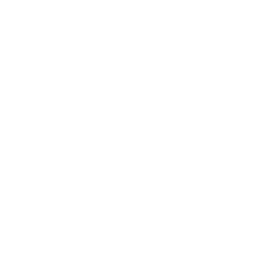
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">ラグ選択を用いた営業担当者（MR）ディテーリングの有効性</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 製薬／コマーシャル・アナリティクス &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

PROC AUTOREG を用いて、専門薬における医師へのディテーリング訪問とサンプル配布が月間処方量に与える影響を評価します。NLAG=3 により処方パターンの自己相関を考慮し、BACKSTEP オプションを適用して有意でないラグ次数を自動的に除外します。ディテーリング訪問1回あたりの限界的なリターンを定量化し、営業組織（フィールドフォース）の配置判断とテリトリーの最適化に役立てます。

合成された月次系列は現在の実行モードでは100観測に制限されていますが、これはディテーリング、サンプリング、フォーミュラリー、および競合の各効果を高い精度で再現するのに十分です。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.DETAILING | ディテーリングおよびサンプル指標を含む月次処方データ | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic monthly detailing and Rx data
   for a specialty pharmaceutical product
   -------------------------------------------------------- */
データ work.detailing;
    呼出 streaminit(42);
    保存 prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    繰返 month_seq = 1 から 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* territory assignment rotates across 12 reps */
        rep_id = cat('REP-', PUT(mod(month_seq - 1, 12) + 1, z3.));
        /* detailing visits per month */
        detail_visits = int(rand('normal', 8, 3));
        もし detail_visits < 0 なら detail_visits = 0;
        もし detail_visits > 20 なら detail_visits = 20;
        /* sample units left with physicians */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* managed care formulary status (binary) */
        formulary_status = (rand('uniform') > 0.2);
        /* competitor share pressure */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* seasonal index */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3) error process */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* prescription model */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        もし new_rx < 0 なら new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        出力;
    終了;
    削除 prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    書式 obs_month monyy7.;
実行;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Rx とディテーリングの基本記述統計量
   -------------------------------------------------------- */
表題 'Rx とディテーリングの基本記述統計量';
処理 平均 データ=work.detailing n mean std MIN MAX;
    変数 new_rx total_rx detail_visits samples_left competitor_share;
    見出 new_rx='新規処方数（NRx）'
          total_rx='総処方数（TRx）'
          detail_visits='ディテーリング訪問回数'
          samples_left='提供サンプル数'
          competitor_share='競合シェア';
実行;

                                                  Rx とディテーリングの基本記述統計量                                                   

                                                  The MEANS Procedure

 Variable          Label                                     N            Mean        Std Dev        Minimum         Maximum
 ---------------------------------------------------------------------------------------------------------------------------
 new_rx            新規処方数（NRx）                              100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          総処方数（TRx）                               100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     ディテーリング訪問回数                             100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      提供サンプル数                                 100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  競合シェア                                 


NOTE: Option TITLE changed to Rx とディテーリングの基本記述統計量.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                    ディテーリング強度と新規処方量                                                     




NOTE: Option TITLE changed to ディテーリング強度と新規処方量.
NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


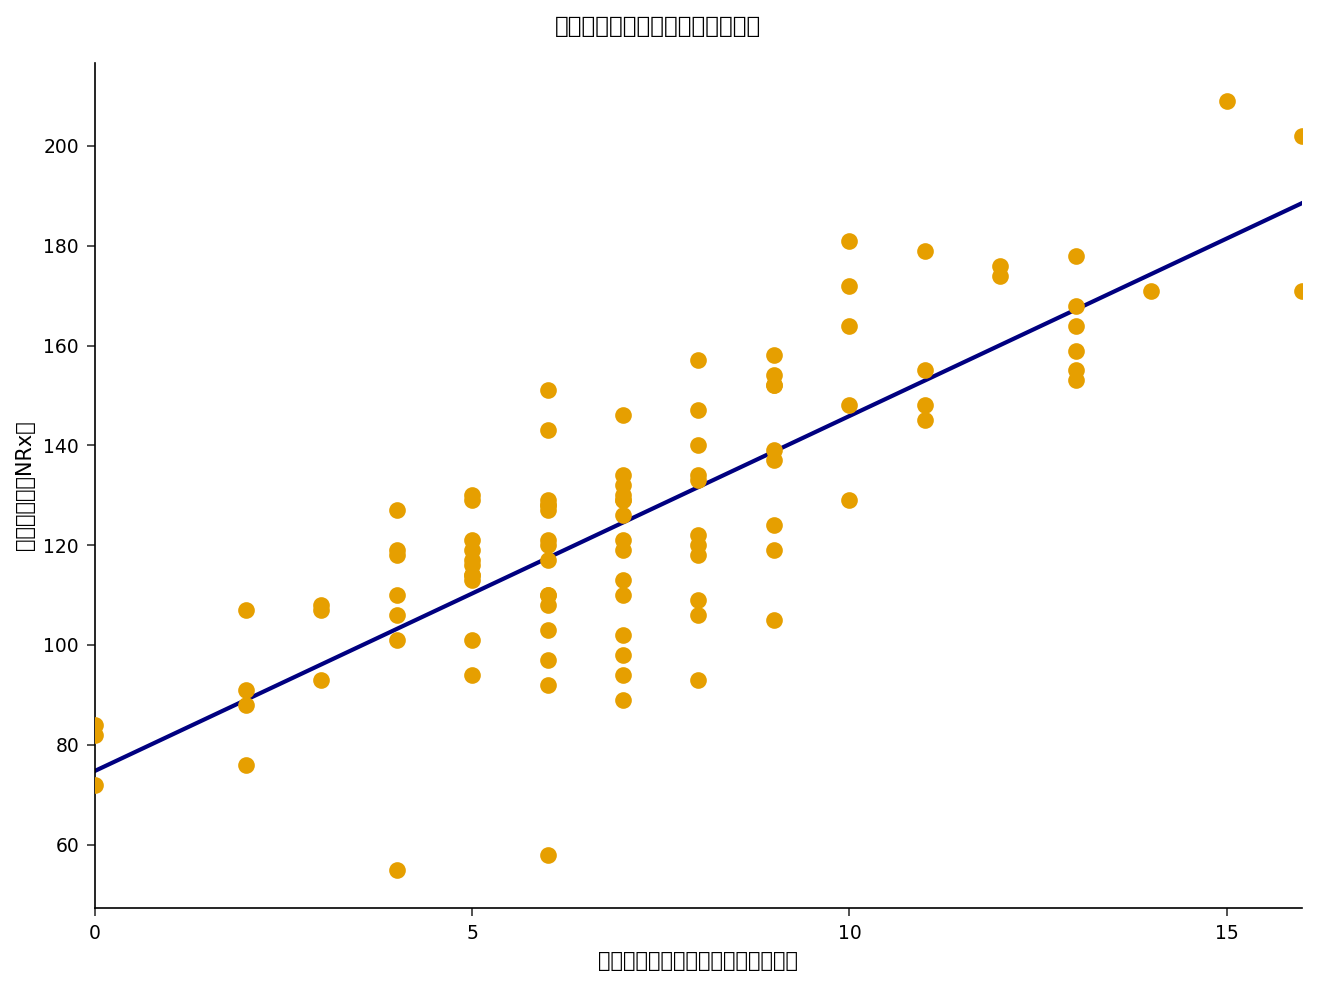

In [3]:
/* --------------------------------------------------------
   ディテーリング訪問回数と新規処方数の散布図
   -------------------------------------------------------- */
表題 'ディテーリング強度と新規処方量';
処理 SGPLOT データ=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS 見出='月あたりのディテーリング訪問回数';
    YAXIS 見出='新規処方数（NRx）';
実行;

---

In [4]:
/* --------------------------------------------------------
   BACKSTEP ラグ選択による自己回帰モデルの当てはめ。
   NLAG=3 は最大 3 次のラグを検定し、BACKSTEP は
   有意でないラグを自動的に除去する。
   -------------------------------------------------------- */
表題 '自己回帰モデル（NLAG=3, BACKSTEP）：新規処方数';
処理 autoreg データ=work.detailing;
    模型 new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    出力 out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
実行;

                                            自己回帰モデル（NLAG=3, BACKSTEP）：新規処方数                                             


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

       


NOTE: Option TITLE changed to 自己回帰モデル（NLAG=3, BACKSTEP）：新規処方数.
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   ROI 計算のためにパラメータ推定値を取得する
   -------------------------------------------------------- */
表題 'パラメータ推定値の取得';
ODS 出力 parameterestimates=work.detail_params;

処理 autoreg データ=work.detailing;
    模型 new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
実行;

ODS 出力 CLOSE;

                                                      パラメータ推定値の取得                                                       


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

       


NOTE: Option TITLE changed to パラメータ推定値の取得.
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   ディテーリング訪問あたりの限界 ROI を計算する。
   ODS ParameterEstimates データセットは Variable 列を
   大文字で格納するため、'DETAIL_VISITS' でフィルタする。
   -------------------------------------------------------- */
表題 'ディテーリング訪問の新規処方への限界効果';
処理 印刷 データ=work.detail_params;
    条件 variable = 'DETAIL_VISITS';
実行;

                                                  ディテーリング訪問の新規処方への限界効果                                                  


  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
-----  -------------  ------------  ------------  ------------  --------
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: Option TITLE changed to ディテーリング訪問の新規処方への限界効果.
NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### 解釈

PROC AUTOREG は100の月次観測に対して処方系列を当てはめました。ディテーリング訪問が1回増えるごとに **月あたり+2.72件の新規処方** が関連し（推定値 2.7158、t = 7.66、p < 0.0001）、医師に残したサンプル1単位ごとに **+1.00 NRx** が加わります（推定値 0.9997、t = 14.73）。これは、サンプリングが対面プロモーションを補強するものの、それを代替するものではないことを示しています。フォーミュラリーへのアクセスは **月あたり+24.78 NRx** に寄与し（t = 13.83）、ディテーリングの有効性の前提条件としてマネージドケアへのアクセスが重要であることを裏付けています。一方、競合シェアは **シェア1単位あたり-42.26 NRx** という強い負の効果を及ぼし（t = -6.96）、ディテーリングだけでは不十分となりうる競争圧力下のテリトリーを示唆しています。切片は 69.56 です。

NLAG=3 と BACKSTEP により、モデルは **2つの自己回帰ラグ** を保持しました。すなわちラグ1（係数 -0.3700、t = -3.78）とラグ2（係数 -0.1995、t = -2.04）で、ラグ3は有意でないため除外されました。補正後のダービン・ワトソン統計量は **1.01** であり、依然として2を大きく下回っており、残差に正の自己相関が残っていることを示しています。したがって AR(2) 構造はこの系列の系列依存性の一部を捉えているものの、その全てを捉えているわけではありません。適合度統計量: SSE = 5527.65、MSE = 58.19、AIC = 701.34、SBC = 722.19、対数尤度 = -342.67。

営業組織の計画では、フォーミュラリーへのアクセスが良好で競合シェアが中程度のテリトリーを対象とすべきであり、そこではディテーリング訪問1回あたりの限界的なリターンが最も高くなります。

---

In [7]:
/* --------------------------------------------------------
   Export fitted values and parameters for field force
   planning dashboard
   -------------------------------------------------------- */
処理 EXPORT データ=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 社外秘
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供元 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>